In [1]:
import pandas as pd
import sqlite3

con = sqlite3.connect("../database/checking-logs.sqlite")

## Load commits (users only)

In [2]:
q = """
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%';
"""
df = pd.io.sql.read_sql(q, con, parse_dates=["timestamp"])
df.head()

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370


## Build date + part of day

In [3]:
df["date"] = df["timestamp"].dt.date
hour = df["timestamp"].dt.hour

df["part"] = pd.cut(
    hour,
    bins=[-1, 3, 9, 16, 23],
    labels=["night", "morning", "afternoon", "evening"]
)

df[["timestamp", "date", "part"]].head()

,timestamp,date,part
0,2020-04-17 05:19:02.744528,2020-04-17,morning
1,2020-04-17 05:22:35.249331,2020-04-17,morning
2,2020-04-17 05:22:45.549397,2020-04-17,morning
3,2020-04-17 05:34:14.691200,2020-04-17,morning
4,2020-04-17 05:34:24.422370,2020-04-17,morning


## Count commits per day by part

In [4]:
daily_parts = (
    df.groupby(["date", "part"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)
daily_parts.head()

/var/folders/32/gyhr77kj37xfbcdxcp3tztfh0000gn/T/ipykernel_70509/2239212714.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["date", "part"])


part,night,morning,afternoon,evening
date,,,,
2020-04-17,0,13,10,0
2020-04-18,0,1,33,35
2020-04-19,2,4,16,11
2020-04-20,0,0,12,13
2020-04-21,0,0,0,25


## Plot (bar chart)


Text(0, 0.5, 'commits')

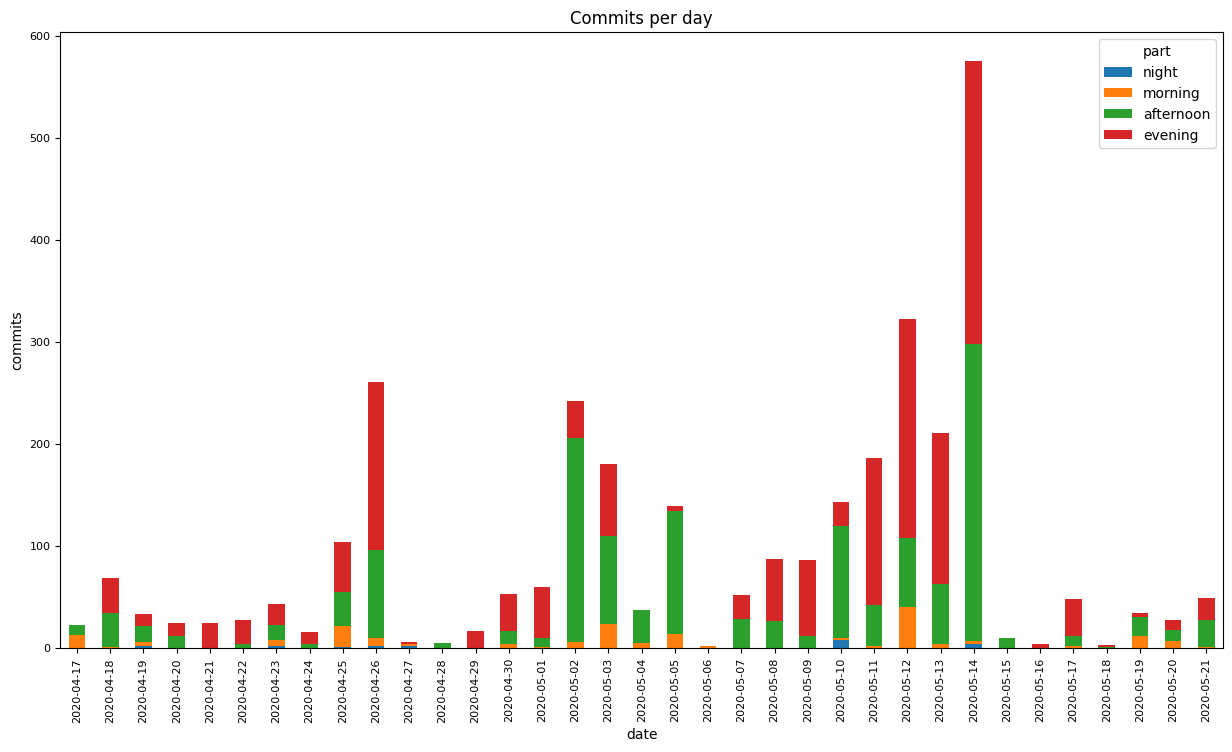

In [5]:
ax = daily_parts.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 8),
    fontsize=8,
    title="Commits per day"
)
ax.tick_params(axis="x", rotation=90)
ax.set_xlabel("date")
ax.set_ylabel("commits")

In [6]:
top2 = daily_parts.sum().sort_values(ascending=False).head(2)
top2

part
evening      1611
afternoon    1391
dtype: int64

In [7]:
total = daily_parts.sum(axis=1)
mask = daily_parts["evening"] > daily_parts["afternoon"]

best_day = total[mask].idxmax()
best_day

datetime.date(2020, 5, 12)

- When do our users usually commit to the labs: in the night, morning, afternoon, or evening?
  The answer is: **<FIRST>** and **<SECOND>**.

- Which day has the most number of commits, and at the same time, the number of commits is higher in the evening than in the afternoon?
  The answer is: **<YYYY-MM-DD>**.

In [8]:
con.close()